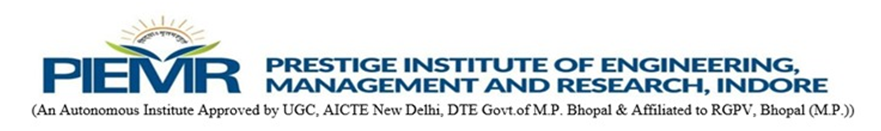

<h2 align="left">Department of Computer Science & Engineering [Internet of Things & Cybersecurity Including Blockchain Technology]</h2>

<h2 align="left">Data Analyatics in IoT & Blockchain </h2>

<h2 align="left"> Course Instructor: Dr. Rajesh Kumar</h2>

#### <h2 align="left">Experiment 5</h2>

<h2 align="left"> LINEAR REGRESSION USING HOUSING DATASET </h2>

<h2 align="Left">Objective</h2>

To implement the Linear Regression algorithm using the Housing dataset for predicting house prices and evaluate the model performance using regression evaluation metrics.


Python Libraries Used

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



STEP 1: Load Dataset

The Housing dataset contains information related to:

Area
Number of bedrooms
Bathrooms
Stories
Parking
Furnishing status
House prices

Read the dataset from the local system.   


In [2]:
file_path = r"C:\Users\rjesh\Housing.csv"

df = pd.read_csv(file_path)
print(df.head())



      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


STEP 2: Explore Dataset

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nDataset Information:\n")
print(df.info())




Dataset Shape: (545, 13)

Columns:

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          

DATA PREPROCESSING

Machine learning models require numerical input.

Convert categorical columns into numerical format using one-hot encoding.

In [4]:
df = pd.get_dummies(df, drop_first=True)

print(df.head())





      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2             1   
1  12250000  8960         4          4        4        3             1   
2  12250000  9960         3          2        2        2             1   
3  12215000  7500         4          2        2        3             1   
4  11410000  7420         4          1        2        2             1   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0              0             0                    0                    1   
1              0             0                    0                    1   
2              0             1                    0                    0   
3              0             1                    0                    1   
4              1             1                    0                    1   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0             1  

DEFINE FEATURES AND TARGET VARIABLE
Target Variable

The target variable is:

price
Feature Variables

All remaining columns are considered input features.

In [5]:
y = df['price']

X = df.drop('price', axis=1)



TRAIN TEST SPLIT

Split the dataset into:

Training data
Testing data

80% data is used for training.

20% data is used for testing.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



Display dataset shapes.

In [7]:
print(X_train.shape)
print(X_test.shape)


(436, 13)
(109, 13)


CREATE LINEAR REGRESSION MODEL

In [8]:
model = LinearRegression()




TRAIN THE MODEL

The model learns the relationship between features and house prices


In [9]:
model.fit(X_train, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


MODEL INTERCEPT AND COEFFICIENTS

Intercept

In [10]:
print(model.intercept_)



260032.35760741588


Coefficients

In [11]:
coeff_df = pd.DataFrame(
    model.coef_,
    X.columns,
    columns=['Coefficient']
)

print(coeff_df)

                                  Coefficient
area                             2.359688e+02
bedrooms                         7.677870e+04
bathrooms                        1.094445e+06
stories                          4.074766e+05
parking                          2.248419e+05
mainroad_yes                     3.679199e+05
guestroom_yes                    2.316100e+05
basement_yes                     3.902512e+05
hotwaterheating_yes              6.846499e+05
airconditioning_yes              7.914267e+05
prefarea_yes                     6.298906e+05
furnishingstatus_semi-furnished -1.268818e+05
furnishingstatus_unfurnished    -4.136451e+05


PREDICTIONS

Predict house prices using testing data.

In [12]:
y_pred = model.predict(X_test)

print(y_pred[:10])



[5164653.90033967 7224722.29802166 3109863.24240338 4612075.3272256
 3294646.25725956 3532275.09556559 5611774.56836476 6368145.98732718
 2722856.95689985 2629405.61585783]


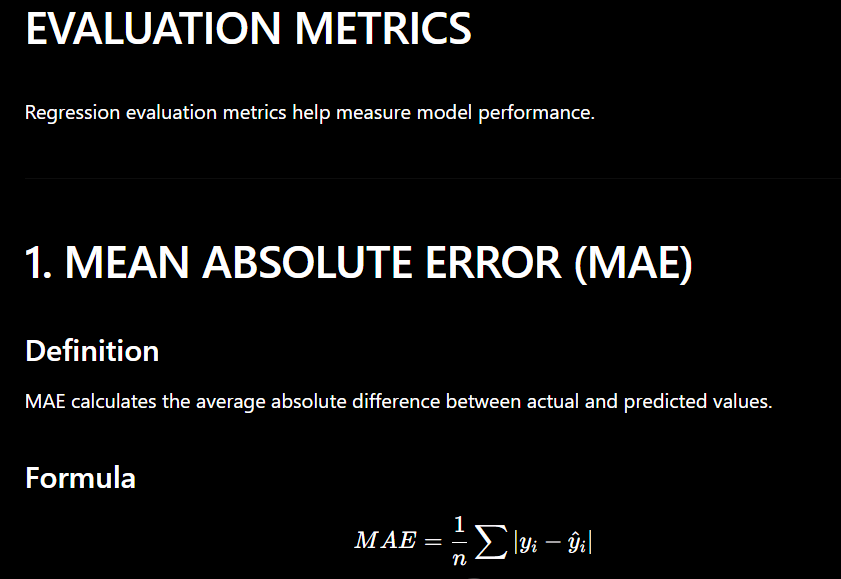
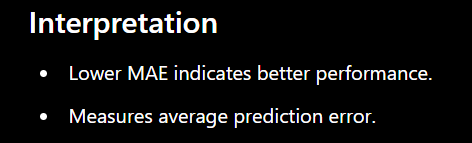


In [13]:
mae = mean_absolute_error(y_test, y_pred)
print(mae)




970043.4039201641


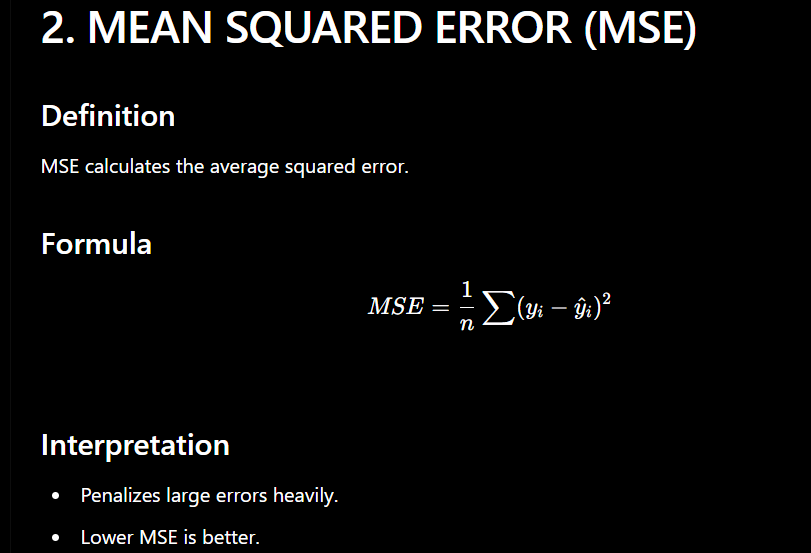




STEP 9: Visualize Clusters

In [14]:

mse = mean_squared_error(y_test, y_pred)
print(mse)



1754318687330.6643


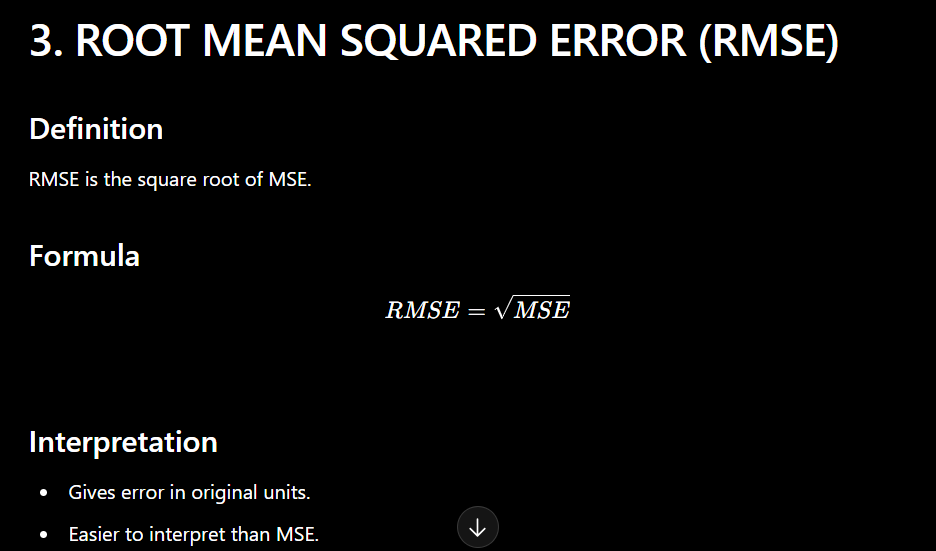

In [15]:
rmse = np.sqrt(mse)
print(rmse)





1324506.9600914388


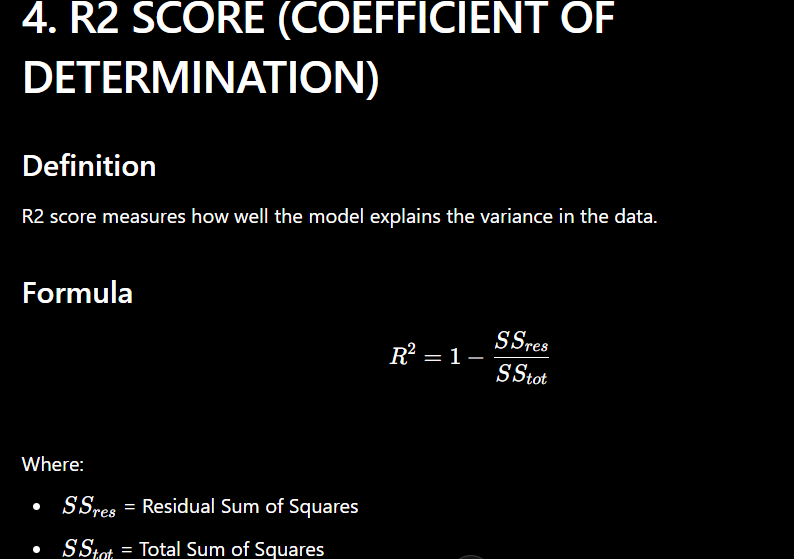
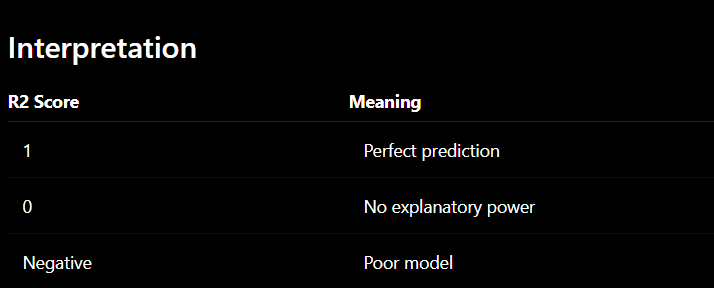

In [16]:
r2 = r2_score(y_test, y_pred)
print(r2)



0.6529242642153184


COMPLETE EVALUATION CODE


In [17]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)



Mean Absolute Error: 970043.4039201641
Mean Squared Error: 1754318687330.6643
Root Mean Squared Error: 1324506.9600914388
R2 Score: 0.6529242642153184


ACTUAL VS PREDICTED COMPARISON

In [18]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

print(comparison.head(10))



     Actual Price  Predicted Price
316       4060000     5.164654e+06
77        6650000     7.224722e+06
360       3710000     3.109863e+06
90        6440000     4.612075e+06
493       2800000     3.294646e+06
209       4900000     3.532275e+06
176       5250000     5.611775e+06
249       4543000     6.368146e+06
516       2450000     2.722857e+06
426       3353000     2.629406e+06


VISUALIZATION

Visualize actual and predicted house prices.

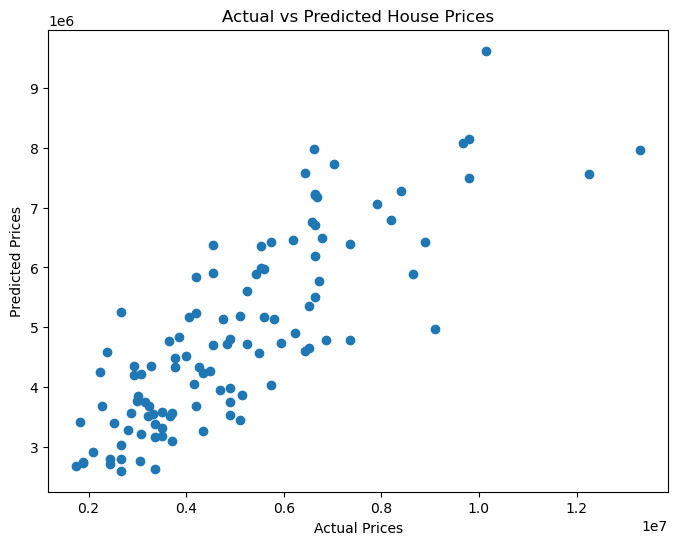

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()





SAVE OUTPUT

Save prediction results into a CSV file.




In [20]:
comparison.to_csv(
    r"C:\Users\rjesh\housing_prediction_output.csv",
    index=False
)

print("Prediction Output Saved Successfully")




Prediction Output Saved Successfully


Residual Analysis

Residuals help us understand prediction errors.

In [21]:
# Calculate residuals

residuals = y_test - y_pred

print(residuals.head())

316   -1.104654e+06
77    -5.747223e+05
360    6.001368e+05
90     1.827925e+06
493   -4.946463e+05
Name: price, dtype: float64


Residual Distribution Plot

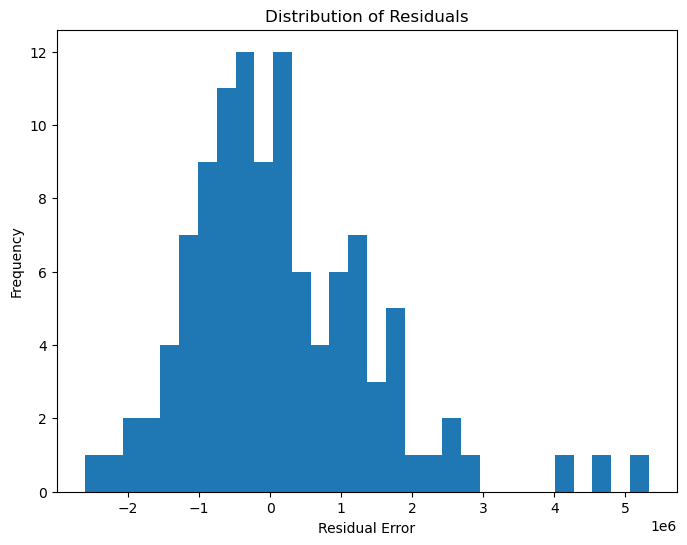

In [22]:
plt.figure(figsize=(8,6))

plt.hist(residuals, bins=30)

plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

Observation

A good Linear Regression model should produce residuals centered around zero and approximately normally distributed.

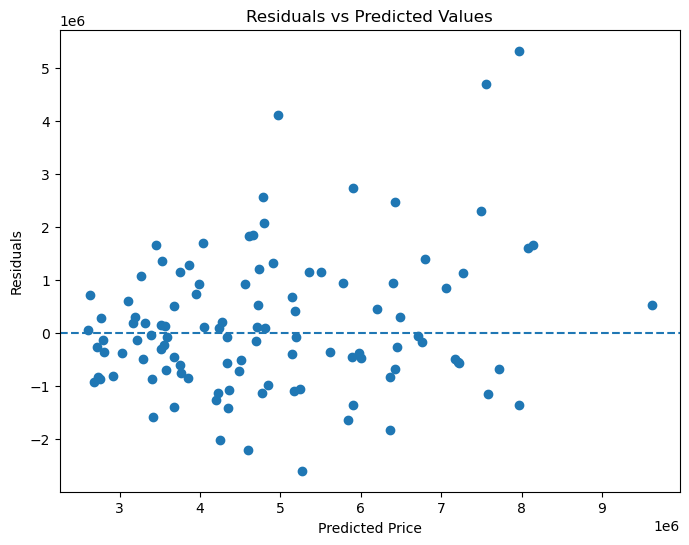

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residuals vs Predicted Values")

plt.show()

Observation

Residuals should be randomly scattered around zero without any visible pattern.

Model Score on Training and Testing Data

Interpretation
Higher R² indicates better performance.
Large difference between train and test scores may indicate overfitting.

Feature Importance Analysis

Linear Regression coefficients indicate feature influence.

In [25]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coeff_df = coeff_df.sort_values(
    by='Coefficient',
    ascending=False
)

print(coeff_df)

                            Feature   Coefficient
2                         bathrooms  1.094445e+06
9               airconditioning_yes  7.914267e+05
8               hotwaterheating_yes  6.846499e+05
10                     prefarea_yes  6.298906e+05
3                           stories  4.074766e+05
7                      basement_yes  3.902512e+05
5                      mainroad_yes  3.679199e+05
6                     guestroom_yes  2.316100e+05
4                           parking  2.248419e+05
1                          bedrooms  7.677870e+04
0                              area  2.359688e+02
11  furnishingstatus_semi-furnished -1.268818e+05
12     furnishingstatus_unfurnished -4.136451e+05


Feature Importance Visualization

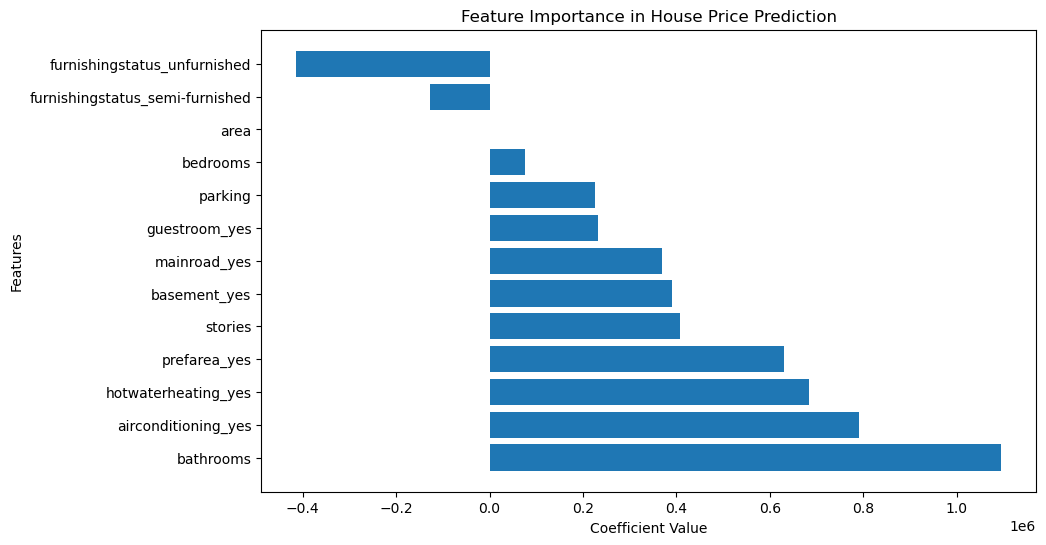

In [26]:
plt.figure(figsize=(10,6))

plt.barh(
    coeff_df['Feature'],
    coeff_df['Coefficient']
)

plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.title("Feature Importance in House Price Prediction")

plt.show()

Predict House Price for New Input

Example prediction.

In [27]:
sample_house = pd.DataFrame({
    'area':[5000],
    'bedrooms':[3],
    'bathrooms':[2],
    'stories':[2],
    'parking':[1],
    'mainroad_yes':[1],
    'guestroom_yes':[0],
    'basement_yes':[1],
    'hotwaterheating_yes':[0],
    'airconditioning_yes':[1],
    'prefarea_yes':[1],
    'furnishingstatus_semi-furnished':[1],
    'furnishingstatus_unfurnished':[0]
})

predicted_price = model.predict(sample_house)

print("Predicted House Price =", predicted_price[0])

Predicted House Price = 6951503.768097271


Correlation Matrix

Useful for understanding relationships among variables.

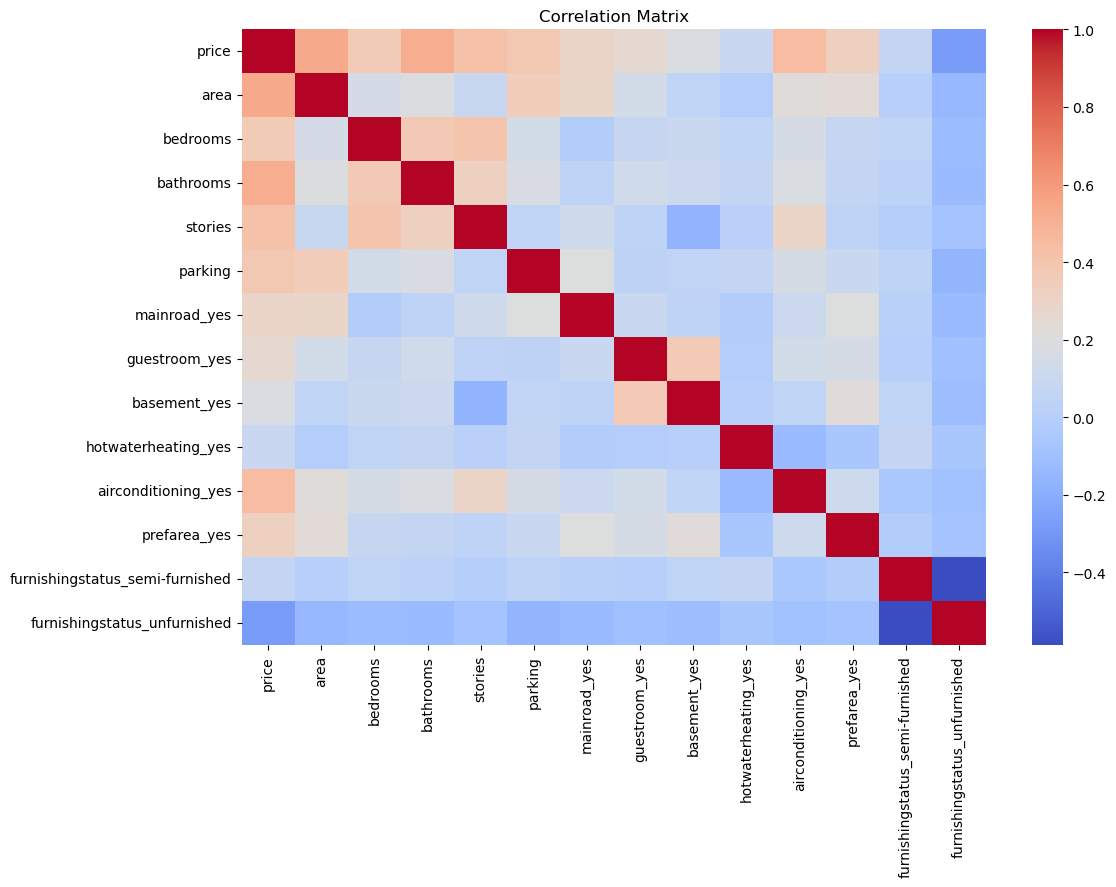

In [28]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

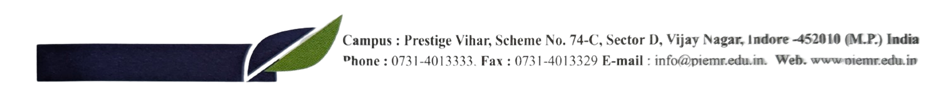